# **Linear Regression in PyTorch**

### **Laboratory Exercise 3** - *Deep Learning Fundamentals*
*From the course module:* ***01_Understanding Deep Learning*** *(Laboratory Task 4)*

**Instruction:** Train a linear regression model in PyTorch using a regression dataset. Use the following parameters:

- Criterion: MSE Loss
- Fully Connected Layers x 2
- Batch Size: 8
- Optimizer: SGD
- Epoch: 1000

## **Overview**

**Linear regression** predicts a continuous value as a weighted sum of the input features:

$$
\hat{y} = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$
<br>

Training adjusts $w$ and $b$ to minimize the **Mean Squared Error (MSE)**:

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$
<br>

Each training step is the same forward pass, error, and backward pass from Laboratory Task 3. PyTorch computes the gradients for us with `loss.backward()` (autograd), and **SGD** applies the update $w \leftarrow w - \eta\,\partial E/\partial w$ with `optimizer.step()`.

**Model architecture** (two fully connected layers, no activation between them, so the model stays linear):

```mermaid
graph LR
    Input["Input<br/>10 features"] --> FC1["FC layer 1<br/>10 → 16"]
    FC1 --> FC2["FC layer 2<br/>16 → 1"]
    FC2 --> Output["Prediction"]
```
<br>

**Dataset:** the *Diabetes* regression dataset from scikit-learn (442 patients, 10 features such as age, BMI, blood pressure, and blood serum measurements). The target is a numeric measure of disease progression one year after baseline.

## **Implementation**

### **Import Libraries**

In [1]:
!pip install numpy torch scikit-learn matplotlib

In [2]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

### **Load the Dataset**

In [3]:
data = load_diabetes()
X, y = data.data, data.target.reshape(-1, 1)

print("Features:", data.feature_names)
print("X shape :", X.shape)
print("y shape :", y.shape)
print(f"y range : {y.min():.0f} to {y.max():.0f}")

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
X shape : (442, 10)
y shape : (442, 1)
y range : 25 to 346


### **Split and Scale the Data**

The data is split 80% for training and 20% for testing. Features and target are standardized using the **training set only** (mean 0, standard deviation 1). Scaling keeps the gradients well-behaved so SGD trains stably.

$$
z = \frac{v-\mu}{\sigma}
$$

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(y_train)

X_train_s = x_scaler.transform(X_train)
X_test_s  = x_scaler.transform(X_test)
y_train_s = y_scaler.transform(y_train)
y_test_s  = y_scaler.transform(y_test)

# Convert to tensors
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train_s, dtype=torch.float32)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test_s,  dtype=torch.float32)

print("Train samples:", len(X_train_t))
print("Test samples :", len(X_test_t))

Train samples: 353
Test samples : 89


### **Create the DataLoader (Batch Size = 8)**

The `DataLoader` feeds the training set to the model in mini-batches of 8 samples, reshuffled every epoch.

In [5]:
BATCH_SIZE = 8

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(42),
)

print("Batches per epoch:", len(train_loader))

Batches per epoch: 45


### **Define the Model (2 Fully Connected Layers)**

- `fc1`: 10 inputs → 16 hidden units
- `fc2`: 16 hidden units → 1 output

No activation function is placed between the layers, so the network computes a purely linear function of the input, which is what makes this a linear regression model.

In [6]:
class LinearRegressionModel(nn.Module):
    def __init__(self, in_features, hidden=16):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden)
        self.fc2 = nn.Linear(hidden, 1)

    def forward(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        return x

model = LinearRegressionModel(in_features=X_train_t.shape[1])
print(model)

LinearRegressionModel(
  (fc1): Linear(in_features=10, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


### **Define the Loss Function and Optimizer**

- **Criterion:** `nn.MSELoss()`
- **Optimizer:** `torch.optim.SGD` with learning rate $\eta = 0.01$ (the task does not fix a learning rate, so a common starting value is used)

In [7]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
EPOCHS = 1000

### **Train the Model (1000 Epochs)**

Each iteration over a batch performs the same steps as Task 3:

1. **Forward pass:** compute predictions
2. **Loss:** compute MSE between predictions and targets
3. **Backward pass:** `loss.backward()` computes the gradients
4. **Update:** `optimizer.step()` applies the SGD update

`optimizer.zero_grad()` clears old gradients, since PyTorch accumulates them by default.

In [8]:
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()          # clear old gradients
        preds = model(xb)              # forward pass
        loss = criterion(preds, yb)    # MSE loss
        loss.backward()                # backward pass
        optimizer.step()               # SGD update

        running_loss += loss.item() * xb.size(0)

    train_loss = running_loss / len(X_train_t)

    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()

    train_losses.append(train_loss)
    test_losses.append(test_loss)

    if epoch == 1 or epoch % 100 == 0:
        print(f"Epoch {epoch:4d}/{EPOCHS} | Train MSE: {train_loss:.4f} | Test MSE: {test_loss:.4f}")

Epoch    1/1000 | Train MSE: 0.8561 | Test MSE: 0.5363
Epoch  100/1000 | Train MSE: 0.4839 | Test MSE: 0.4637
Epoch  200/1000 | Train MSE: 0.4836 | Test MSE: 0.4756
Epoch  300/1000 | Train MSE: 0.4811 | Test MSE: 0.4770
Epoch  400/1000 | Train MSE: 0.4819 | Test MSE: 0.4785
Epoch  500/1000 | Train MSE: 0.4810 | Test MSE: 0.4788
Epoch  600/1000 | Train MSE: 0.4803 | Test MSE: 0.4742
Epoch  700/1000 | Train MSE: 0.4807 | Test MSE: 0.4746
Epoch  800/1000 | Train MSE: 0.4790 | Test MSE: 0.4836
Epoch  900/1000 | Train MSE: 0.4788 | Test MSE: 0.4746
Epoch 1000/1000 | Train MSE: 0.4783 | Test MSE: 0.4817


### **Training Curve**

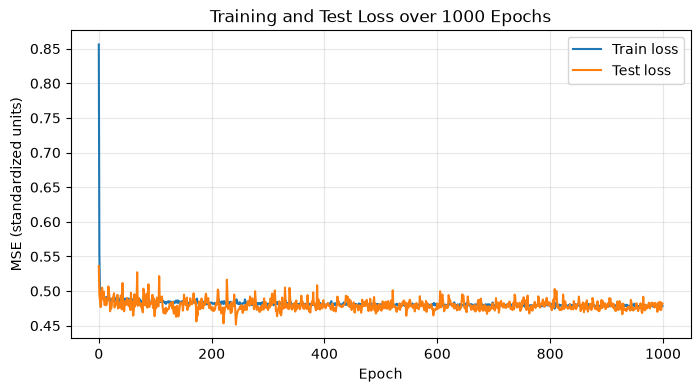

In [9]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train loss")
plt.plot(test_losses, label="Test loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (standardized units)")
plt.title("Training and Test Loss over 1000 Epochs")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Evaluate the Model**

The predictions are converted back to the original target scale so the error can be read in real units. The coefficient of determination measures how much of the variance the model explains:

$$
R^2 = 1-\frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}
$$

In [10]:
model.eval()
with torch.no_grad():
    pred_test_s = model(X_test_t).numpy()

pred_test = y_scaler.inverse_transform(pred_test_s)

mse  = np.mean((y_test - pred_test) ** 2)
rmse = np.sqrt(mse)
r2   = r2_score(y_test, pred_test)

print(f"Test MSE  : {mse:.2f}")
print(f"Test RMSE : {rmse:.2f}")
print(f"Test R^2  : {r2:.4f}")

Test MSE  : 2927.16
Test RMSE : 54.10
Test R^2  : 0.4475


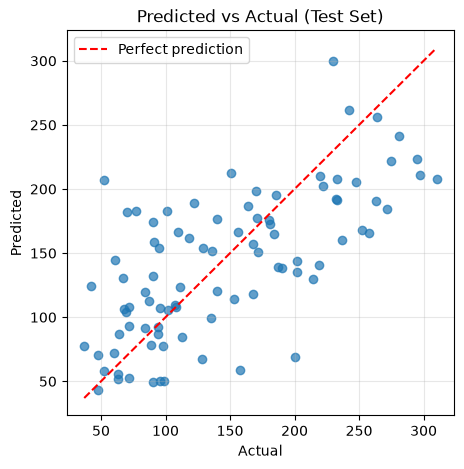

In [11]:
plt.figure(figsize=(5, 5))
plt.scatter(y_test, pred_test, alpha=0.7)
lims = [min(y_test.min(), pred_test.min()), max(y_test.max(), pred_test.max())]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Test Set)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### **Sanity Check: Compare with Closed-Form Linear Regression**

Ordinary least squares has an exact solution. A correctly trained linear model should reach a test error close to it.

In [12]:
ols = LinearRegression().fit(X_train_s, y_train_s)
ols_pred = y_scaler.inverse_transform(ols.predict(X_test_s))

print(f"PyTorch (SGD) -> Test MSE: {mse:.2f} | R^2: {r2:.4f}")
print(f"Closed-form   -> Test MSE: {np.mean((y_test - ols_pred) ** 2):.2f} | R^2: {r2_score(y_test, ols_pred):.4f}")

PyTorch (SGD) -> Test MSE: 2927.16 | R^2: 0.4475
Closed-form   -> Test MSE: 2900.19 | R^2: 0.4526


## **Final Answer**

| Setting | Value |
|---|---|
| Dataset | scikit-learn Diabetes (442 samples, 10 features) |
| Criterion | `nn.MSELoss()` |
| Architecture | `Linear(10, 16)` → `Linear(16, 1)` |
| Batch size | 8 (45 batches per epoch) |
| Optimizer | `SGD`, lr = 0.01 |
| Epochs | 1000 |

<br>

| Result | Value |
|---|---|
| Final train MSE (standardized) | 0.4783 |
| Final test MSE (standardized) | 0.4817 |
| Test MSE (original units) | 2927.16 |
| Test RMSE (original units) | 54.10 |
| Test $R^2$ | 0.4475 |

**Interpretation**

The training loss falls quickly, from 0.86 in the first epoch to about 0.48 by epoch 100, then stays flat for the remaining epochs. This means the model reached the best linear fit early and the extra epochs added little. Train and test losses are close to each other, so the model is not overfitting.

The PyTorch model reaches $R^2 = 0.4475$ on unseen data, almost identical to the closed-form least-squares solution ($R^2 = 0.4526$). This confirms that SGD training converged to essentially the optimal linear model. The small remaining gap comes from the noise that mini-batch SGD adds to the weights at a constant learning rate.

**Conclusion:**

The two-layer linear network trained with MSE loss, SGD, batch size 8, and 1000 epochs explains about 45% of the variance in the diabetes progression target. An $R^2$ of this size is typical for a linear model on this dataset, since the relationship between the features and the target is only partly linear. Adding a non-linear activation such as ReLU between the two layers, or using a richer model, could capture more of it.